<a href="https://colab.research.google.com/github/maimuna-noshin/LLM-Model-for-Med-VQA/blob/main/Ollama_testing_splitting_open_close_answer.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Step 1: Install System Dependencies

In [1]:
!apt-get update -q
!apt-get install -y zstd pciutils -q

Get:1 https://cli.github.com/packages stable InRelease [3,917 B]
Get:2 https://cloud.r-project.org/bin/linux/ubuntu jammy-cran40/ InRelease [3,632 B]
Get:3 https://developer.download.nvidia.com/compute/cuda/repos/ubuntu2204/x86_64  InRelease [1,581 B]
Get:4 https://cli.github.com/packages stable/main amd64 Packages [356 B]
Get:5 https://cloud.r-project.org/bin/linux/ubuntu jammy-cran40/ Packages [89.0 kB]
Get:6 https://developer.download.nvidia.com/compute/cuda/repos/ubuntu2204/x86_64  Packages [2,608 kB]
Hit:7 http://archive.ubuntu.com/ubuntu jammy InRelease
Get:8 http://security.ubuntu.com/ubuntu jammy-security InRelease [129 kB]
Get:9 http://archive.ubuntu.com/ubuntu jammy-updates InRelease [128 kB]
Get:10 https://r2u.stat.illinois.edu/ubuntu jammy InRelease [6,555 B]
Get:11 https://r2u.stat.illinois.edu/ubuntu jammy/main all Packages [10.1 MB]
Get:12 http://security.ubuntu.com/ubuntu jammy-security/universe amd64 Packages [1,292 kB]
Get:13 http://archive.ubuntu.com/ubuntu jammy-bac

# Step 2: Install & Start Ollama

In [12]:
import threading
import subprocess
import time

!curl -fsSL https://ollama.com/install.sh | sh

def run_ollama_serve():
    subprocess.Popen(["ollama", "serve"], stdout=subprocess.DEVNULL, stderr=subprocess.DEVNULL)

thread = threading.Thread(target=run_ollama_serve)
thread.start()
time.sleep(10)

>>> Installing ollama to /usr/local
>>> Downloading ollama-linux-amd64.tar.zst
######################################################################## 100.0%
>>> Creating ollama user...
>>> Adding ollama user to video group...
>>> Adding current user to ollama group...
>>> Creating ollama systemd service...
>>> NVIDIA GPU installed.
>>> The Ollama API is now available at 127.0.0.1:11434.
>>> Install complete. Run "ollama" from the command line.


# Step 3: Pull Free Vision Models

In [13]:
!ollama pull llama3.2-vision
#!ollama pull bakllava

# Step 4: Install Python Libraries

In [14]:
!pip install -q langchain-ollama ollama datasets colab-xterm

# Step 5: Prompt Design — Closed vs Open Questions

In [15]:
import ollama
from IPython.display import display, Markdown

def get_answer_type(answer):
    """
    Returns 'closed' if the answer is a yes/no type,
    otherwise returns 'open'.
    """
    closed_answers = {"yes", "no"}
    if str(answer).strip().lower() in closed_answers:
        return "closed"
    return "open"

def prompt_closed(question, answer) :
  return f"""
            You are a medical imaging expert specializing in radiology.
            Analyze the provided medical image carefully.

            This is a CLOSED question that requires a YES or NO answer.

            QUESTION: {question}
            CORRECT ANSWER: {answer}

            Your task:
            1. Identify the imaging modality (X-ray, CT, MRI, Ultrasound, etc.).
            2. Identify the anatomical region and key structures visible.
            3. Analyze the specific feature the question asks about.
            4. Generate a Chain-of-Thought (CoT) reasoning that logically leads to the correct answer.
            5. Explain why the answer is "{answer}" using specific visual evidence from the image.

            Output format:
            STEP 1 - MODALITY: [Identify imaging type and visual cues]
            STEP 2 - ANATOMY: [Region, plane/view, key landmarks]
            STEP 3 - TARGETED ANALYSIS: [Specifically analyze what the question asks about]
            STEP 4 - EVIDENCE: [Visual features that support the answer YES or NO]
            STEP 5 - ANSWER VALIDATION: The answer is "{answer}" because [specific visual justification].
            FINAL ANSWER: {answer}
        """

def prompt_open(question, answer) :
    return f"""
        Context: You are a medical imaging expert specializing in radiology. your task is to analyze the given medical image,question and answer carefully to generate CoT thinking steps to reach the proper answer.


        Task instruction: You need to follow following thinking steps to generate your reasoning:
              1. Analyze the provided medical image carefully using structured critical thinking.
              2. Identify the imaging modality (X-ray, CT, MRI, Ultrasound, PET, etc.).
              3. Analyze the question and answer provided:
                    - QUESTION: {question}
                    - ANSWER: {answer}
              4. Generate detailed thinking steps based on the image, question, and answer.
              5. Validate why the given answer is correct using visual evidence from the image.
              6. Use modality-specific descriptors:
                    - CT: hyperdense / hypodense
                    - MRI: hyperintense / hypointense
                    - Ultrasound: echogenic / anechoic
              7. If findings are ambiguous, state your confidence level instead of guessing.
              8. Your response MUST strictly follow the Output Thinking Step Format below.




        Output thinking step format:
          STEP 1: IMAGE MODALITY IDENTIFICATION
              - What imaging technique was used? (X-ray, CT, MRI, Ultrasound, PET, etc.)
              - What are the visual cues that confirm this? (grayscale range, texture, artifact patterns)
              - Is contrast enhancement present?

          STEP 2: ANATOMICAL REGION & ORIENTATION
              - Which body region/organ system is depicted?
              - What is the imaging plane/view? (axial, coronal, sagittal, AP, lateral, etc.)
              - Identify key anatomical landmarks visible.

          STEP 3: SYSTEMATIC IMAGE SURVEY
              - Scan the image systematically (e.g., center-to-periphery or region-by-region).
              - Note: density/signal intensities, tissue boundaries, symmetry, size/shape of structures.
              - Use appropriate descriptors: hyperdense/hypodense (CT), hyperintense/hypointense (MRI), echogenic (US).
          STEP 4: ABNORMALITY DETECTION
              - List ALL visible abnormalities:
                * Location (specific anatomical site)
                * Size/extent (if estimable)
                * Morphology (shape, margins, borders)
                * Density/signal characteristics
                * Associated findings (mass effect, edema, calcification, etc.)
              - Note any relevant NEGATIVE findings (absence of expected structures).

        STEP 5: DIFFERENTIAL DIAGNOSIS REASONING
              - Based on findings, list possible diagnoses ranked by likelihood.
              - For each: explain which visual features support or contradict it.
              - Apply relevant clinical reasoning (e.g., distribution pattern, typical demographics).

        STEP 6: CORRELATION WITH QUESTION
              - Re-read the question: {question}
              - Which findings directly answer this question?
              - Eliminate irrelevant differentials based on what is specifically being asked.

        STEP 7: ANSWER VALIDATION
              - The provided answer is: {answer}
              - Does the image evidence support this answer? Explain why.
              - Which specific visual features are the KEY indicators for this answer?
              - Are there any alternative interpretations? Why are they less likely?

        STEP 8: FINAL REASONING SUMMARY
              - Concisely summarize the critical reasoning chain:
                [Image type] → [Key finding] → [Clinical implication] → [Answer]

      """

def promptDesign(question, answer):
  answer_type = get_answer_type(answer)
  if answer_type == "closed":
        return prompt_closed(question, answer)
  else :
        return prompt_open(question, answer)






# Step 6: LLM Caller

In [16]:
def call_llm(image_path, prompt):

  response = ollama.chat(
      model="llama3.2-vision",
      messages=[{
          "role": "user",
          "content": prompt,
          "images": [image_path]
      }]
  )
  content = response['message']['content']
  message = response['message']
  display(Markdown(content))
  return message, content

# Step 7: Load VQA-RAD Dataset

In [17]:
from datasets import load_dataset

dataset = load_dataset("flaviagiammarino/vqa-rad")
print(dataset)

DatasetDict({
    train: Dataset({
        features: ['image', 'question', 'answer'],
        num_rows: 1793
    })
    test: Dataset({
        features: ['image', 'question', 'answer'],
        num_rows: 451
    })
})


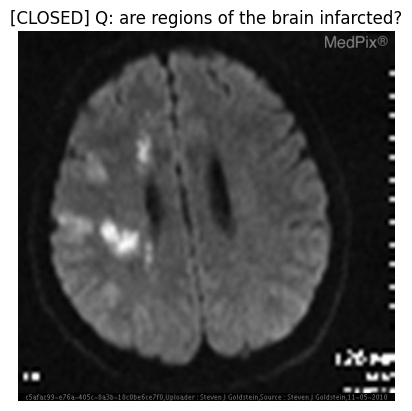

**STEP 1 - MODALITY:** The imaging modality used is Magnetic Resonance Imaging (MRI), as indicated by the presence of a T2-weighted or FLAIR sequence, which is commonly used to visualize white matter lesions and infarcts.

**STEP 2 - ANATOMY:** The anatomical region of interest is the brain, specifically the cerebral cortex and white matter. Key structures visible include the ventricles, sulci, and gyri.

**STEP 3 - TARGETED ANALYSIS:** The question asks about regions of the brain that are infarcted. Infarcts appear as hyperintense lesions on T2-weighted or FLAIR sequences due to the presence of edema and inflammation.

**STEP 4 - EVIDENCE:** Visual features that support the answer "yes" include:

*   Hyperintense lesions in the white matter, which are characteristic of infarcts.
*   The lesions are scattered throughout the cerebral cortex, indicating multiple infarcts.
*   The lesions are surrounded by edema, which is a common feature of infarcts.

**STEP 5 - ANSWER VALIDATION:** The answer is "yes" because the hyperintense lesions in the white matter, surrounded by edema, are consistent with infarcts.

**FINAL ANSWER:** yes

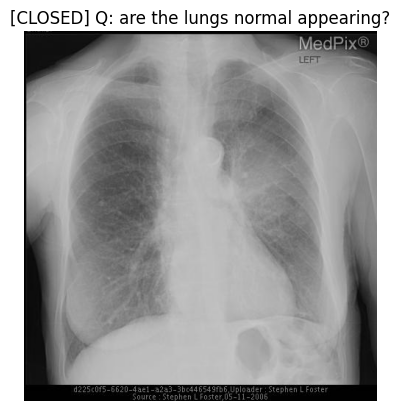

**STEP 1 - MODALITY:** The imaging modality used is an X-ray, as indicated by the characteristic radiographic features and the lack of contrast agents or other modalities' typical appearances.

**STEP 2 - ANATOMY:** The anatomical region imaged is the thorax, with the lungs being the primary focus. Key structures visible include the rib cage, mediastinum, and diaphragm.

**STEP 3 - TARGETED ANALYSIS:** The question asks about the normal appearance of the lungs. In X-ray images, lungs appear as darker (or more radiolucent) areas due to their air-filled nature.

**STEP 4 - EVIDENCE:** Upon examination, the lungs do not appear as expected. Instead of being dark (radiolucent), they are lighter (more radiopaque) than expected. This suggests an abnormality.

**STEP 5 - ANSWER VALIDATION:** The answer is "no" because the lungs' appearance is not normal; they are not radiolucent as they should be, indicating an issue.

**FINAL ANSWER:** no

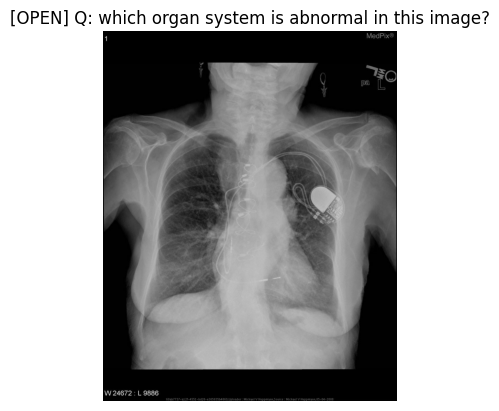

**STEP 1: IMAGE MODALITY IDENTIFICATION**

The image is an X-ray, specifically a chest X-ray. This can be determined by the overall appearance of the image, which shows the bony structure of the thoracic cage, the lungs, and the heart. The X-ray is in grayscale, which is typical for X-ray images.

**STEP 2: ANATOMICAL REGION & ORIENTATION**

The image depicts the thorax, focusing on the chest cavity. The imaging plane is an anteroposterior (AP) view, as indicated by the orientation of the spine and the position of the heart.

**STEP 3: SYSTEMATIC IMAGE SURVEY**

- **Lungs:** The lungs appear normal in size and shape. No significant consolidation or pneumonias are visible.
- **Heart:** The heart appears slightly enlarged, which could be a sign of heart failure or other cardiac issues. This is the most relevant finding for answering the question about the abnormality in the image.
- **Thoracic Cage:** The bony structure of the thoracic cage appears normal.

**STEP 4: ABNORMALITY DETECTION**

- **Enlarged Heart:** The most notable finding is the enlargement of the heart. This is the key abnormality that needs to be addressed.

**STEP 5: DIFFERENTIAL DIAGNOSIS REASONING**

- **Enlarged Heart:** The most likely cause of an enlarged heart in this context would be heart failure or another cardiac condition. This is supported by the lack of other significant findings that could explain the heart's size.

**STEP 6: CORRELATION WITH QUESTION**

- The question asks which organ system is abnormal in this image. The answer provided is "cardiovascular." The key finding of an enlarged heart directly answers this question.

**STEP 7: ANSWER VALIDATION**

- The image evidence supports the answer that the cardiovascular system is abnormal. The enlarged heart is the critical finding that supports this conclusion.

**STEP 8: FINAL REASONING SUMMARY**

- **X-ray** → **Enlarged Heart** → **Cardiac Issues** → **Cardiovascular System Abnormality**



The final answer is: **Cardiovascular**

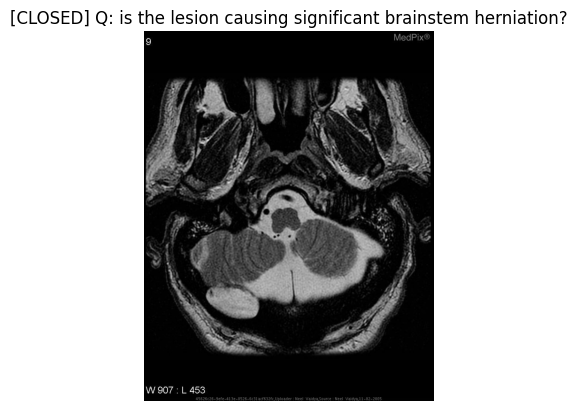

**Step 1: Modality Identification**

The provided medical image is an MRI (Magnetic Resonance Imaging) scan, specifically a T2-weighted axial view. This can be determined by the image's characteristics, such as the high-contrast representation of soft tissues and the presence of fluid- or fluid-like structures.

**Step 2: Anatomical Region and Key Structures**

The image focuses on the brainstem and its surrounding structures. The brainstem is visible in the center of the image, with the cerebellum below it. The fourth ventricle is also clearly seen.

**Step 3: Targeted Analysis - Brainstem Herniation**

The question specifically asks about the presence of significant brainstem herniation. Brainstem herniation occurs when the brainstem is displaced from its normal position, usually due to an increase in intracranial pressure. This can lead to serious consequences, including brainstem damage.

**Step 4: Evidence - Visual Analysis**

Upon visual inspection, there is no evidence of the brainstem being displaced or herniated. The structures around the brainstem, such as the cerebellum and the fourth ventricle, appear normal. There is no visible displacement or distortion of these structures that would suggest a significant brainstem herniation.

**Step 5: Answer Validation**

The answer is "no" because there is no visual evidence of the brainstem being displaced or herniated. The structures surrounding the brainstem appear normal, and there are no signs of the usual consequences of brainstem herniation.

**Final Answer**

The final answer is: no.

In [18]:
import matplotlib.pyplot as plt

NUM_SAMPLES   = 4

for i in range(NUM_SAMPLES):
    sample = dataset["train"][i]
    question = sample["question"]
    answer   = sample["answer"]
    atype    = get_answer_type(answer)

    # Save image
    image_path = f"temp_{i}.jpg"
    sample["image"].save(image_path)

    # Show image
    plt.imshow(sample["image"])
    plt.axis("off")
    plt.title(f"[{atype.upper()}] Q: {question}")
    plt.show()

    # Build prompt
    prompt = promptDesign(question, answer)

    call_llm(image_path, prompt)

